In [25]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from torchdiffeq import odeint
from learning_gradient_flow import sindy_tools

A_mat = torch.tensor([[0.0, 3.0], [-1.0, -0.2]])

def damped_oscillator(t, state):
    """
    Damped oscillator system dynamics.

    Args:
        t: Time point (unused, but required by odeint)
        state: Tensor of shape [2, 1] with state variables [position, velocity]

    Returns:
        Tensor of shape [2, 1] with derivatives
    """
    # state shape: [2, 1]
    return A_mat @ state

x0 = torch.tensor([[1.0], [0.0]])  # Shape: [2, 1]
t_span = torch.linspace(0, 10, 501)

# Generate the ground truth solution
true_solution = odeint(damped_oscillator, x0.flatten(), t_span)

# Add noise to the solution
nl = 0.1
noise = nl * torch.randn(true_solution.shape)
X_data = true_solution + noise # n_t, n_states

In [26]:
lib = sindy_tools.create_sindy_library(X_data.shape[1], 2, True)
Theta = lib(X_data) # n_t, P, where P depends on degree and original n_states

['width: 10', 'stride: 1', 'p: 10']
K = 481


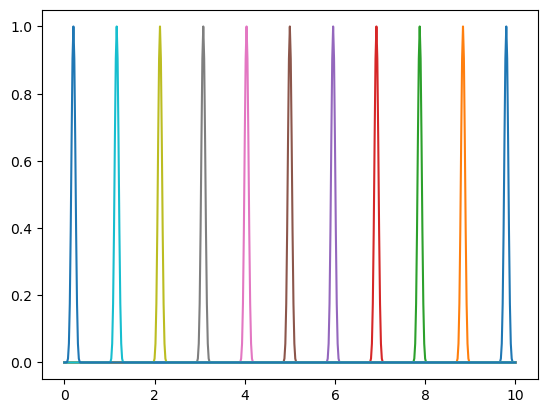

In [27]:
# follow guidelines to set L = M/25. L is total support size, M is number of timesteps
n_t = X_data.shape[0]
# width = n_t//20
width = (n_t//25)//2

test_mat_kwargs = {'width': width, 'stride': 1, 'p': 10}
# automate for each key
print([f'{k}: {v}' for k, v in test_mat_kwargs.items()])

Phi, dPhi = sindy_tools.create_test_mats(t_span,**test_mat_kwargs)
K = Phi.shape[1]
print(f'K = {K}')

plt.figure()
if K < 10:
    plt.plot(t_span, Phi, label='Bump function φ(t)')
else:
    k_inds = np.arange(0, K, K//10).astype(int)
    plt.plot(t_span, Phi[:, k_inds], label='Bump function φ(t)')

# plt.figure()
# plt.plot(t_span, dPhi[:,-1], label='Bump function derivative φ\'(t)')

# plt.plot(t_span, Theta)

# dot(Y) = Theta @ Xi
# (n_t, n_state) = (n_t, P) @ (P, n_state))

# Or weak form
# (K, n_state) = (K, P) @ (P, n_state)

In [28]:
lhs_vec, rhs_mat = sindy_tools.assemble_weak_matrices(X_data, Theta, t_span, test_mat_kwargs=test_mat_kwargs)

print(f'LHS vector shape: {lhs_vec.shape}')
print(f'RHS matrix shape: {rhs_mat.shape}')

rcond = None
rtol = 1e-5
atol = 1e-7

Xi = torch.linalg.lstsq(rhs_mat, lhs_vec, rcond=rcond).solution
goal_Xi = torch.tensor([[0.0, 0.0], [A_mat[0, 0], A_mat[1,0]],
                        [A_mat[0, 1], A_mat[1,1]], [0.0, 0.0],
                        [0.0, 0.0], [0.0, 0.0]])
Xi_error_weak = Xi - goal_Xi
# get y_pred via integrating
predictor = sindy_tools.create_predictor(Xi, lib)
sindy_system = lambda t, state: predictor(state)  # SINDy system function
x_pred = odeint(sindy_system, x0, t_span, rtol=rtol, atol=atol).squeeze()
# get error at end


dxdt, Theta_m2 = sindy_tools.assemble_strong_matrices(X_data, Theta, t_span)

Xi_strong = torch.linalg.lstsq(Theta_m2, dxdt, rcond=rcond).solution
Xi_error_strong = Xi_strong - goal_Xi

predictor_strong = sindy_tools.create_predictor(Xi_strong, lib)
sindy_system_strong = lambda t, state: predictor_strong(state)  # SINDy system function
x_pred_strong = odeint(sindy_system_strong, x0, t_span, rtol=rtol, atol=atol).squeeze()
# get error at end
error_pred_weak = torch.norm(x_pred-true_solution) / torch.norm(true_solution)
error_pred_strong = torch.norm(x_pred_strong-true_solution) / torch.norm(true_solution)


coeff_error_weak = torch.linalg.norm(Xi_error_weak, ord=1) / torch.linalg.norm(goal_Xi, ord=1)
coeff_error_strong = torch.linalg.norm(Xi_error_strong, ord=1) / torch.linalg.norm(goal_Xi, ord=1)

print(f'coeff_error_weak: {coeff_error_weak}')
print(f'coeff_error_strong: {coeff_error_strong}')
print(f'error_pred_weak: {error_pred_weak}')
print(f'error_pred_strong: {error_pred_strong}')

# create dicts to store these for multiple runs. Check if it exists, if not create
# if it does, append to it
# just save errors
# also add nl to this
try:
    dict_errors
except NameError:
    dict_errors = {}
    dict_errors['nl'] = []
    dict_errors['coeff_error_weak'] = []
    dict_errors['coeff_error_strong'] = []
    dict_errors['error_pred_weak'] = []
    dict_errors['error_pred_strong'] = []

dict_errors['nl'].append(nl)
dict_errors['coeff_error_weak'].append(coeff_error_weak.item())
dict_errors['coeff_error_strong'].append(coeff_error_strong.item())
dict_errors['error_pred_weak'].append(error_pred_weak.item())
dict_errors['error_pred_strong'].append(error_pred_strong.item())

LHS vector shape: torch.Size([481, 2])
RHS matrix shape: torch.Size([481, 6])
coeff_error_weak: 0.2536104917526245
coeff_error_strong: 0.5303574204444885
error_pred_weak: 0.16661176085472107
error_pred_strong: 0.8690313696861267


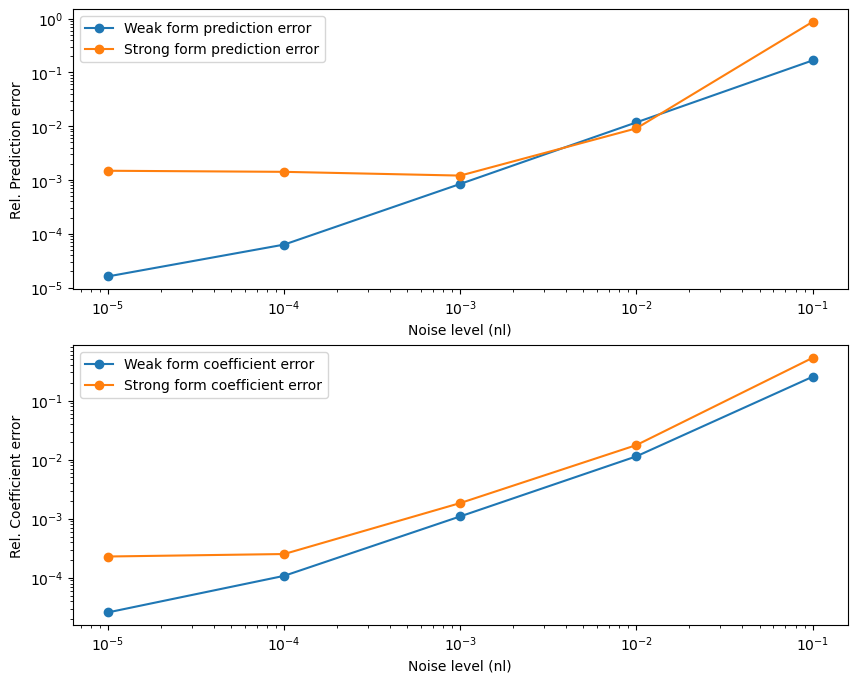

In [29]:
# sort dict by nl
sort_inds = np.argsort(dict_errors['nl'])
# just sort for each key in dict
for key in dict_errors.keys():
    dict_errors[key] = list(np.array(dict_errors[key])[sort_inds])


# plot these metrics vs nl for the two methods. two subplots, nl on x on both. first subplot is prediction error, 2nd is coefficient error
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(dict_errors['nl'], dict_errors['error_pred_weak'], 'o-', label='Weak form prediction error')
ax[0].plot(dict_errors['nl'], dict_errors['error_pred_strong'], 'o-', label='Strong form prediction error')
ax[0].set_xlabel('Noise level (nl)')
ax[0].set_ylabel('Rel. Prediction error')
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].legend()

ax[1].plot(dict_errors['nl'], dict_errors['coeff_error_weak'], 'o-', label='Weak form coefficient error')
ax[1].plot(dict_errors['nl'], dict_errors['coeff_error_strong'], 'o-', label='Strong form coefficient error')
ax[1].set_xlabel('Noise level (nl)')
ax[1].set_ylabel('Rel. Coefficient error')
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].legend()


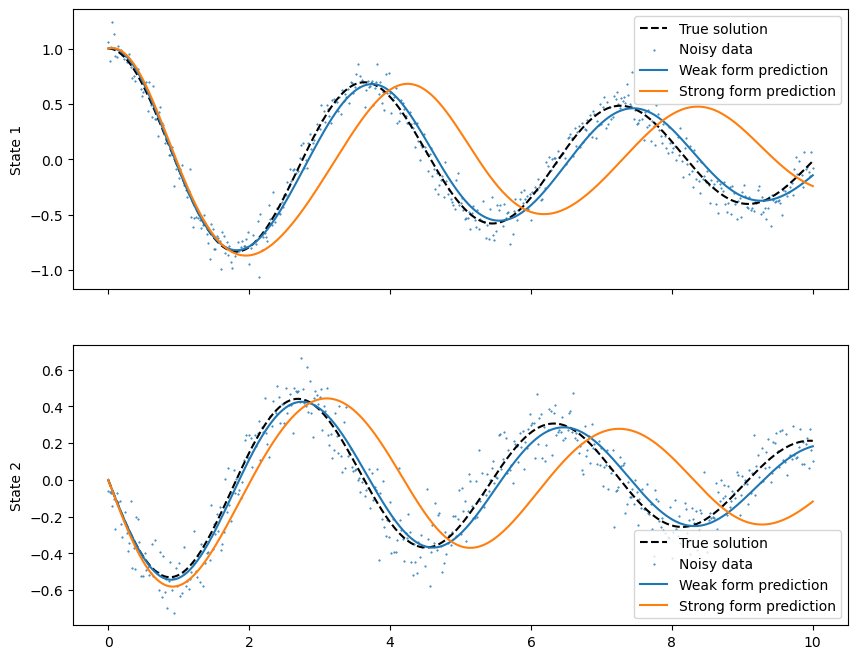

In [30]:
# subplots
fig, ax = plt.subplots(X_data.shape[1], 1, figsize=(10, 8), sharex=True)
for i in range(X_data.shape[1]):
    ax[i].plot(t_span, true_solution[:, i], '--k', label='True solution')
    ax[i].scatter(t_span, X_data[:, i], s=1, marker='.', label='Noisy data')
    ax[i].plot(t_span, x_pred[:, i], label='Weak form prediction')
    ax[i].plot(t_span, x_pred_strong[:, i], label='Strong form prediction')
    ax[i].set_ylabel(f'State {i+1}')
    ax[i].legend()